# LSTM-VAE Baseline Detector v1 -- SWaT A1/A2 (2015/2016)
## Dataset clasico de iTrust -- Version referencia de la literatura

### Descripcion del dataset

| Archivo | Periodo | Filas | Etiquetas |
|---------|---------|-------|-----------|
| SWaT_Dataset_Normal_v1.xlsx | 22-28 dic 2015 | ~495,000 | Solo Normal (7 dias) |
| SWaT_Dataset_Attack_v0.xlsx | 28 dic 2015 - 2 ene 2016 | 449,919 | Normal + Attack (41 ataques) |

**51 sensores**: 25 continuos (FIT, LIT, AIT, DPIT, PIT) + 26 discretos (MV, P, UV)

### Diferencias respecto a datasets A11/A12 (Mar 2026)

| Aspecto | A11/A12 (Mar 2026) | **A1/A2 (2015/2016)** |
|---------|--------------------|-----------------------|
| Duracion normal | 8h/dia | **7 dias continuos** |
| Ventanas train | ~3,000-10,000 | **~50,000+** |
| Ataques | 11 tipos, 5 min c/u | **41 tipos, duracion variable** |
| Label column | attack_label (0/1) | **Normal/Attack (string)** |
| Timestamps | t_stamp (24h) | **Timestamp (AM/PM)** |
| Separador col | coma CSV | **xlsx, columnas con espacios** |

### Protocolo de evaluacion

```
Train : Normal_v1 completo (60/20/20 cronologico)
Eval  : Attack_v0 completo (normales + ataques etiquetados)
```

**Metricas reportadas en literatura (A1/A2):** ROC-AUC > 0.90, F1 > 0.70


## 0. Imports

In [1]:
import json, joblib, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
import warnings; warnings.filterwarnings('ignore')


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas

In [7]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

# Ubicar los archivos en data/clean/ del repositorio
CLEAN_DIR    = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A1 & A2_Dec 2015'
NORMAL_XLSX  = CLEAN_DIR / 'SWaT_Dataset_Normal_v1.xlsx'
ATTACK_XLSX  = CLEAN_DIR / 'SWaT_Dataset_Attack_v0.xlsx'

SAVE_DIR     = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_swat_a1a2_v1'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('Normal xlsx :', NORMAL_XLSX.exists())
print('Attack xlsx :', ATTACK_XLSX.exists())
print('Save dir    :', SAVE_DIR)


Normal xlsx : True
Attack xlsx : True
Save dir    : d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_swat_a1a2_v1


## 2. Hiperparametros

Valores de referencia de la literatura para LSTM-VAE en SWaT A1/A2.
Con ~50,000 ventanas de entrenamiento, se usa mayor capacidad que A11/A12.

| Parametro | Valor | Justificacion |
|---|---|---|
| WINDOW_SIZE | 60 | Estandar en literatura SWaT |
| STRIDE | 10 | Balance velocidad/solapamiento con 7 dias de datos |
| HIDDEN_SIZE | 128 | Buena capacidad para 51 sensores |
| LATENT_DIM | 64 | Espacio latente informativo |
| BETA | 0.05 | KL suave -- evitar posterior collapse |
| ALPHA | 0.85 | Mayor peso en continuas donde se expresan ataques |
| DROPOUT | 0.20 | Regularizacion estandar |
| LR | 5e-4 | Convergencia estable |
| BATCH_SIZE | 256 | Eficiente con dataset grande |


In [8]:
# Definicion de columnas (51 sensores, sin espacios al limpiar)
CONTINUOUS_COLS = [
    'FIT101', 'LIT101', 'AIT201', 'AIT202', 'AIT203', 'FIT201',
    'DPIT301', 'FIT301', 'LIT301',
    'AIT401', 'AIT402', 'FIT401', 'LIT401',
    'AIT501', 'AIT502', 'AIT503', 'AIT504',
    'FIT501', 'FIT502', 'FIT503', 'FIT504',
    'PIT501', 'PIT502', 'PIT503', 'FIT601',
]
DISCRETE_COLS = [
    'MV101', 'P101', 'P102',
    'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206',
    'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302',
    'P401', 'P402', 'P403', 'P404', 'UV401',
    'P501', 'P502',
    'P601', 'P602', 'P603',
]
ALL_SENSOR_COLS = CONTINUOUS_COLS + DISCRETE_COLS

# Hiperparametros
WINDOW_SIZE  = 60
STRIDE       = 10
HIDDEN_SIZE  = 128
NUM_LAYERS   = 2
LATENT_DIM   = 64
DISC_HIDDEN  = 64
BETA         = 0.05
ALPHA        = 0.85
DROPOUT      = 0.20
LR           = 5e-4
BATCH_SIZE   = 256
MAX_EPOCHS   = 100
PATIENCE     = 15
CLIP_VAL     = 5.0
WARMUP_SEC   = 1800   # 30 min warmup (readme: v0 tenia 30 min de drenaje)

# Protocolo de evaluacion
EXCLUDED_IDS = []     # Se llenara tras diagnostico inicial
CONSEC_K     = 3

print(f'Sensores: {len(CONTINUOUS_COLS)} continuos | {len(DISCRETE_COLS)} discretos')
print(f'Window={WINDOW_SIZE} | Stride={STRIDE} | Clip={CLIP_VAL}')
print(f'hidden={HIDDEN_SIZE} | latent={LATENT_DIM} | beta={BETA} | alpha={ALPHA}')


Sensores: 25 continuos | 26 discretos
Window=60 | Stride=10 | Clip=5.0
hidden=128 | latent=64 | beta=0.05 | alpha=0.85


## 3. Carga y preprocesamiento

### Diferencias respecto a A11/A12

1. **Formato xlsx** con header en fila 1 (no CSV con t_stamp).
2. **Timestamps en formato AM/PM** (`28/12/2015 10:00:00 AM`).
3. **Columnas con espacios** al principio -- se stripean al cargar.
4. **Label column** = `Normal/Attack` (string, no entero).
   Typo en datos originales: `'A ttack'` -> se corrige a `'Attack'`.
5. **Warmup de 30 min** (segun readme: v0 incluia drenaje inicial;
   v1 ya lo remueve, pero se aplica warmup adicional por seguridad).
6. **Sin NaN**: el dataset A1/A2 no tiene valores faltantes.


In [9]:
def load_swat_xlsx(path, label_is_string=True):
    """Carga un archivo XLSX de SWaT A1/A2.
    - Fila 0 del Excel es el header real (header=1 en pandas).
    - Limpia espacios en nombres de columnas.
    - Parsea timestamp AM/PM.
    - Normaliza label column a 0/1.
    """
    df = pd.read_excel(path, header=1)
    # Limpiar espacios en nombres de columnas
    df.columns = [c.strip() for c in df.columns]
    # Parsear timestamp
    df['Timestamp'] = pd.to_datetime(
        df['Timestamp'].astype(str).str.strip(),
        format='%d/%m/%Y %I:%M:%S %p'
    )
    df = df.sort_values('Timestamp').reset_index(drop=True)
    # Normalizar sensores a float
    for col in ALL_SENSOR_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    if label_is_string and 'Normal/Attack' in df.columns:
        df['Normal/Attack'] = df['Normal/Attack'].astype(str).str.strip()
        df['Normal/Attack'] = df['Normal/Attack'].replace('A ttack', 'Attack')
        df['attack_label']  = (df['Normal/Attack'] == 'Attack').astype(int)
    else:
        df['attack_label'] = 0
    return df

# Cargar Normal (train)
print('Cargando Normal_v1...')
df_normal = load_swat_xlsx(NORMAL_XLSX, label_is_string=False)
# Aplicar warmup (v1 ya removio los 30 min iniciales, pero aplicamos
# un pequeno warmup por seguridad de estabilizacion del sistema)
t0_n = df_normal['Timestamp'].min()
df_normal = df_normal[
    df_normal['Timestamp'] >= t0_n + pd.Timedelta(seconds=WARMUP_SEC)
].reset_index(drop=True)
print(f'  Normal_v1: {len(df_normal):,} filas | '
      f'{df_normal["Timestamp"].min()} -> {df_normal["Timestamp"].max()}')

# Cargar Attack (eval)
print('Cargando Attack_v0...')
df_attack = load_swat_xlsx(ATTACK_XLSX, label_is_string=True)
print(f'  Attack_v0: {len(df_attack):,} filas | '
      f'Normal={( df_attack["attack_label"]==0).sum():,} | '
      f'Attack={(df_attack["attack_label"]==1).sum():,} ({100*df_attack["attack_label"].mean():.1f}%)')


Cargando Normal_v1...
  Normal_v1: 493,200 filas | 2015-12-22 17:00:00 -> 2015-12-28 09:59:59
Cargando Attack_v0...
  Attack_v0: 449,919 filas | Normal=395,298 | Attack=54,621 (12.1%)


In [10]:
# Split cronologico 60/20/20 sobre datos normales
n = len(df_normal)
df_train = df_normal.iloc[:int(n*0.60)].copy().reset_index(drop=True)
df_val   = df_normal.iloc[int(n*0.60):int(n*0.80)].copy().reset_index(drop=True)
df_test  = df_normal.iloc[int(n*0.80):].copy().reset_index(drop=True)

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
print(f'Train: {df_train["Timestamp"].min()} -> {df_train["Timestamp"].max()}')
print(f'Val  : {df_val["Timestamp"].min()} -> {df_val["Timestamp"].max()}')

# No hay NaN en este dataset (verificado)
nan_count = df_train[ALL_SENSOR_COLS].isna().sum().sum()
print(f'NaN en train: {nan_count}')


Train: 295,920 | Val: 98,640 | Test: 98,640
Train: 2015-12-22 17:00:00 -> 2015-12-26 03:11:59
Val  : 2015-12-26 03:12:00 -> 2015-12-27 06:35:59
NaN en train: 0


## 4. Escalado

- `StandardScaler` fiteado en train normal.
- Clip a `[-5, 5]` para robustez ante outliers de sensores.
- Discretas normalizadas a `[0, 1]` por valor maximo.

In [11]:
scaler_cont = StandardScaler()
scaler_cont.fit(df_train[CONTINUOUS_COLS].values)
disc_max = df_train[DISCRETE_COLS].max().replace(0, 1)

def scale_df(df):
    df = df.copy()
    df[CONTINUOUS_COLS] = np.clip(
        scaler_cont.transform(df[CONTINUOUS_COLS].values),
        -CLIP_VAL, CLIP_VAL
    )
    df[DISCRETE_COLS] = (df[DISCRETE_COLS] / disc_max).clip(0, 1)
    return df

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)

joblib.dump(scaler_cont,        SAVE_DIR / 'scaler_cont.pkl')
joblib.dump(disc_max.to_dict(), SAVE_DIR / 'disc_max_dict.pkl')

rng = df_train_sc[CONTINUOUS_COLS].values
print(f'Train cont escalado: [{rng.min():.2f}, {rng.max():.2f}]  (esperado: [-5, 5])')
print(f'Scaler guardado: {SAVE_DIR / "scaler_cont.pkl"}')


Train cont escalado: [-5.00, 5.00]  (esperado: [-5, 5])
Scaler guardado: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_swat_a1a2_v1\scaler_cont.pkl


## 5. Ventanas deslizantes

Formato `(N, T, C)` -- LSTM espera secuencia primero.
Variables discretas: summary stats por ventana (mode, transitions, nunique, dominance).

In [12]:
def create_windows(arr, ws, stride):
    wins = [arr[i:i+ws] for i in range(0, len(arr)-ws+1, stride)]
    return np.array(wins, dtype=np.float32) if wins \
           else np.empty((0, ws, arr.shape[1]), dtype=np.float32)

def summarize_discrete_windows(disc_windows, dcols):
    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(dcols):
            v = w[:, j]; s = pd.Series(v)
            feats[f'{col}__mode']        = s.mode().iloc[0] if len(s.mode()) > 0 else 0.0
            feats[f'{col}__transitions'] = float(np.sum(v[1:] != v[:-1]))
            feats[f'{col}__nunique']     = float(len(np.unique(v)))
            feats[f'{col}__dominance']   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

def build_windows(df_sc, ws, stride):
    wc  = create_windows(df_sc[CONTINUOUS_COLS].values.astype(np.float32), ws, stride)
    wd  = create_windows(df_sc[DISCRETE_COLS].values.astype(np.float32),   ws, stride)
    wds = summarize_discrete_windows(wd, DISCRETE_COLS).values.astype(np.float32)
    return wc, wds

X_tr_c, X_tr_d = build_windows(df_train_sc, WINDOW_SIZE, STRIDE)
X_va_c, X_va_d = build_windows(df_val_sc,   WINDOW_SIZE, STRIDE)

DISC_DIM = X_tr_d.shape[1]
print(f'Train: {X_tr_c.shape}  (N, T, C)')
print(f'Val  : {X_va_c.shape}')
print(f'Disc summary dim: {DISC_DIM}  ({len(DISCRETE_COLS)} vars x 4 stats)')


Train: (29587, 60, 25)  (N, T, C)
Val  : (9859, 60, 25)
Disc summary dim: 104  (26 vars x 4 stats)


## 6. Arquitectura LSTM-VAE Hibrido

```
Continuas (N,T,25) -> LSTMEncoder -> mu, logvar -> z
                                                    |
                                                    v
                                           LSTMDecoder -> x_hat (N,T,25)

Discretas (N,D)   -> MLPEncoder -> h_d -> MLPDecoder -> xd_hat
```
**Perdida:** `L = alpha*(MSE_cont + beta*KL) + (1-alpha)*MSE_disc`

**Score:** `alpha*MSE_cont + (1-alpha)*MSE_disc`  (KL solo en train)

In [13]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, latent_dim, dropout):
        super().__init__()
        self.lstm      = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.drop      = nn.Dropout(dropout)
        self.fc_mu     = nn.Linear(hidden_size, latent_dim)
        self.fc_logvar = nn.Linear(hidden_size, latent_dim)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h_last = self.drop(h[-1])
        return self.fc_mu(h_last), self.fc_logvar(h_last)

class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_size, num_layers, output_size, seq_len, dropout):
        super().__init__()
        self.seq_len    = seq_len
        self.num_layers = num_layers
        self.fc_h0      = nn.Linear(latent_dim, hidden_size)
        self.lstm       = nn.LSTM(latent_dim, hidden_size, num_layers, batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0.0)
        self.drop       = nn.Dropout(dropout)
        self.fc_out     = nn.Linear(hidden_size, output_size)
    def forward(self, z):
        h0 = torch.tanh(self.fc_h0(z)).unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(z.unsqueeze(1).repeat(1, self.seq_len, 1), (h0, c0))
        return self.fc_out(self.drop(out))

class HybridLSTMVAE(nn.Module):
    def __init__(self, cont_size, seq_len, disc_dim,
                 hidden_size=128, num_layers=2, latent_dim=64,
                 disc_hidden=64, dropout=0.2):
        super().__init__()
        self.encoder_cont = LSTMEncoder(cont_size, hidden_size, num_layers, latent_dim, dropout)
        self.decoder_cont = LSTMDecoder(latent_dim, hidden_size, num_layers, cont_size, seq_len, dropout)
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden, disc_hidden // 2), nn.ReLU())
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden // 2, disc_hidden), nn.ReLU(),
            nn.Linear(disc_hidden, disc_dim))
    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu
    def forward(self, xc, xd):
        mu, logvar = self.encoder_cont(xc)
        z = self.reparameterize(mu, logvar)
        return self.decoder_cont(z), self.decoder_disc(self.encoder_disc(xd)), mu, logvar

def elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, alpha, beta):
    mse_c = nn.functional.mse_loss(xc_hat, xc)
    mse_d = nn.functional.mse_loss(xd_hat, xd)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return alpha*(mse_c + beta*kl) + (1-alpha)*mse_d, mse_c, mse_d, kl

model = HybridLSTMVAE(
    cont_size   = len(CONTINUOUS_COLS),
    seq_len     = WINDOW_SIZE,
    disc_dim    = DISC_DIM,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    latent_dim  = LATENT_DIM,
    disc_hidden = DISC_HIDDEN,
    dropout     = DROPOUT
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Parametros totales: {n_params:,}')
print(f'  Encoder LSTM: {sum(p.numel() for p in model.encoder_cont.parameters()):,}')
print(f'  Decoder LSTM: {sum(p.numel() for p in model.decoder_cont.parameters()):,}')


Parametros totales: 488,609
  Encoder LSTM: 227,968
  Decoder LSTM: 242,969


## 7. Entrenamiento

In [14]:
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_tr_c, dtype=torch.float32),
                  torch.tensor(X_tr_d, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_va_c, dtype=torch.float32),
                  torch.tensor(X_va_d, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-6
)

best_val, best_wts, no_improve, best_ep = float('inf'), None, 0, 1
train_hist, val_hist, hist_mse_c, hist_mse_d, hist_kl = [], [], [], [], []

print(f'Batch={BATCH_SIZE} | LR={LR:.1e} | MaxEp={MAX_EPOCHS} | Patience={PATIENCE}')
print(f'beta={BETA} | alpha={ALPHA}')
print(f'Train batches/ep: {len(train_loader):,}')

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    tl = tmse_c = tmse_d = tkl = 0.0
    for xc, xd in train_loader:
        xc, xd = xc.to(device), xd.to(device)
        optimizer.zero_grad()
        xc_hat, xd_hat, mu, logvar = model(xc, xd)
        loss, mc, md, kl = elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, ALPHA, BETA)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        tl += loss.item(); tmse_c += mc.item(); tmse_d += md.item(); tkl += kl.item()

    nb = len(train_loader)
    tl /= nb; tmse_c /= nb; tmse_d /= nb; tkl /= nb

    model.eval()
    vl = 0.0
    with torch.no_grad():
        for xc, xd in val_loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat, mu, logvar = model(xc, xd)
            vl += elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, ALPHA, BETA)[0].item()
    vl /= len(val_loader)

    scheduler.step(vl)
    train_hist.append(tl); val_hist.append(vl)
    hist_mse_c.append(tmse_c); hist_mse_d.append(tmse_d); hist_kl.append(tkl)

    if vl < best_val - 1e-6:
        best_val = vl; best_ep = epoch; no_improve = 0
        best_wts = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        no_improve += 1

    if epoch % 10 == 0:
        print(f'Ep {epoch:4d}/{MAX_EPOCHS} | Train:{tl:.5f} '
              f'(mse_c={tmse_c:.4f} kl={tkl:.4f}) | Val:{vl:.5f} | Best:{best_val:.5f}(ep{best_ep})')
    if no_improve >= PATIENCE:
        print(f'Early stop ep{epoch}.'); break

model.load_state_dict(best_wts)
model.eval()
print(f'Mejor val:{best_val:.5f} ep{best_ep}')


Batch=256 | LR=5.0e-04 | MaxEp=100 | Patience=15
beta=0.05 | alpha=0.85
Train batches/ep: 115
Ep   10/100 | Train:0.12555 (mse_c=0.1217 kl=0.4976) | Val:0.18181 | Best:0.18181(ep10)
Ep   20/100 | Train:0.10761 (mse_c=0.1059 kl=0.4021) | Val:0.17781 | Best:0.17516(ep19)
Ep   30/100 | Train:0.09677 (mse_c=0.0962 kl=0.3460) | Val:0.16339 | Best:0.16219(ep26)
Ep   40/100 | Train:0.09049 (mse_c=0.0905 kl=0.3144) | Val:0.15911 | Best:0.15911(ep40)
Ep   50/100 | Train:0.08913 (mse_c=0.0892 kl=0.3092) | Val:0.15897 | Best:0.15610(ep45)
Ep   60/100 | Train:0.08642 (mse_c=0.0868 kl=0.2934) | Val:0.15744 | Best:0.15504(ep54)
Early stop ep69.
Mejor val:0.15504 ep54


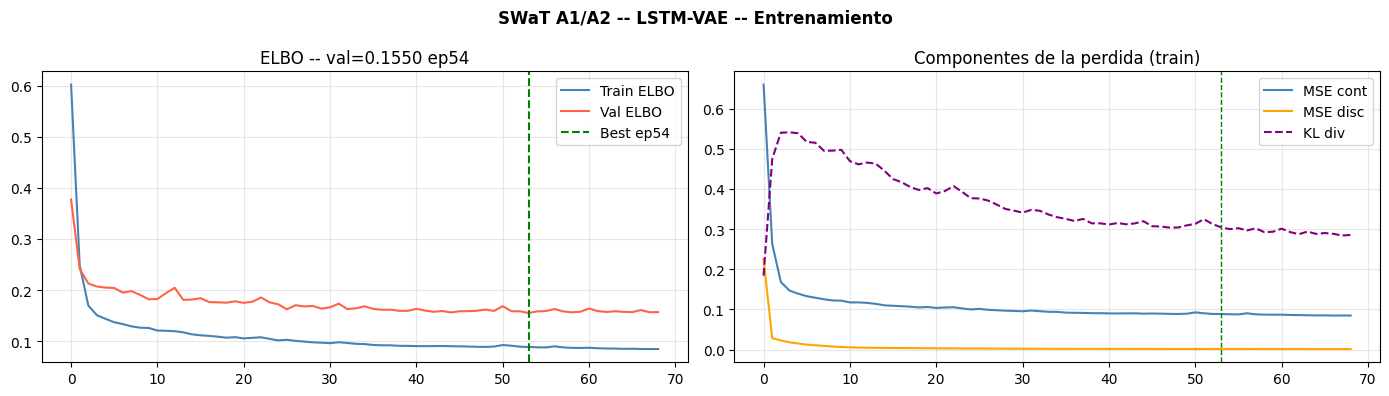

In [15]:
# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_hist, label='Train ELBO', color='steelblue', lw=1.5)
axes[0].plot(val_hist,   label='Val ELBO',   color='tomato',    lw=1.5)
axes[0].axvline(best_ep-1, color='green', linestyle='--', lw=1.5, label=f'Best ep{best_ep}')
axes[0].set_title(f'ELBO -- val={best_val:.4f} ep{best_ep}')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_mse_c, label='MSE cont', color='steelblue', lw=1.5)
axes[1].plot(hist_mse_d, label='MSE disc', color='orange',    lw=1.5)
axes[1].plot(hist_kl,    label='KL div',   color='purple',    lw=1.5, linestyle='--')
axes[1].axvline(best_ep-1, color='green', linestyle='--', lw=1)
axes[1].set_title('Componentes de la perdida (train)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('SWaT A1/A2 -- LSTM-VAE -- Entrenamiento', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'training_curve.png'), dpi=120, bbox_inches='tight')
plt.show()


## 8. Evaluacion supervisada -- Attack_v0

### 8a. Ventanas de evaluacion con metadatos

In [16]:
# Escalar Attack_v0 completo con el scaler de train
df_eval_sc = df_attack.copy()
df_eval_sc[CONTINUOUS_COLS] = np.clip(
    scaler_cont.transform(df_eval_sc[CONTINUOUS_COLS].values),
    -CLIP_VAL, CLIP_VAL
)
df_eval_sc[DISCRETE_COLS] = (df_eval_sc[DISCRETE_COLS] / disc_max).clip(0, 1)

cont_arr   = df_eval_sc[CONTINUOUS_COLS].values.astype(np.float32)
disc_arr   = df_eval_sc[DISCRETE_COLS].values.astype(np.float32)
labs_arr   = df_eval_sc['attack_label'].values
tstamp_arr = df_eval_sc['Timestamp'].values

wins_c, wins_d, meta_rows = [], [], []
for s in range(0, len(cont_arr) - WINDOW_SIZE + 1, STRIDE):
    wins_c.append(cont_arr[s:s+WINDOW_SIZE])
    wins_d.append(disc_arr[s:s+WINDOW_SIZE])
    seg_labs = labs_arr[s:s+WINDOW_SIZE]
    meta_rows.append({
        'y'           : int(np.any(seg_labs == 1)),
        'attack_frac' : float(np.mean(seg_labs == 1)),
        't_start'     : tstamp_arr[s],
    })

X_eval_c = np.array(wins_c, dtype=np.float32)
X_eval_d = summarize_discrete_windows(
    np.array(wins_d, dtype=np.float32), DISCRETE_COLS
).values.astype(np.float32)
df_wins  = pd.DataFrame(meta_rows)
y_all    = df_wins['y'].values

print(f'Ventanas eval: {len(df_wins):,}')
print(f'  Normal (y=0): {(y_all==0).sum():,}')
print(f'  Ataque (y=1): {(y_all==1).sum():,}  ({100*y_all.mean():.1f}%)')
assert len(X_eval_c) == len(y_all) == len(df_wins)
print('Shape OK')


Ventanas eval: 44,986
  Normal (y=0): 39,320
  Ataque (y=1): 5,666  (12.6%)
Shape OK


### 8b. Computo de scores y distribucion de referencia

Error medio NORMAL: 1.79855
Error medio ATAQUE: 7.17360  (ratio: 3.99x)
ROC-AUC completo (referencia): 0.8170


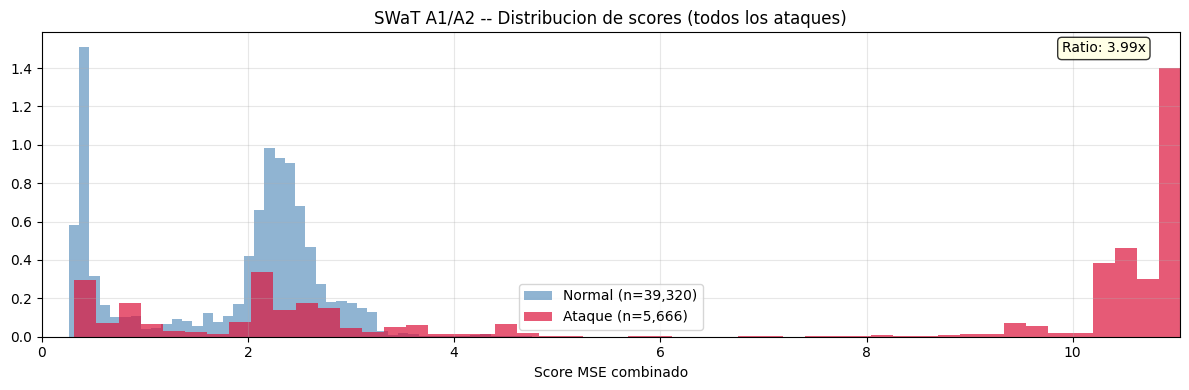

In [17]:
def recon_scores(model, Xc, Xd, alpha, bs=512):
    loader = DataLoader(TensorDataset(torch.tensor(Xc, dtype=torch.float32),
                                      torch.tensor(Xd, dtype=torch.float32)),
                        batch_size=bs, shuffle=False)
    ec_l, ed_l = [], []
    model.eval()
    with torch.no_grad():
        for xc, xd in loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat, mu, _ = model(xc, xd)
            ec_l.extend(torch.mean((xc_hat-xc)**2, dim=(1,2)).cpu().numpy())
            ed_l.extend(torch.mean((xd_hat-xd)**2, dim=1).cpu().numpy())
    ec = np.array(ec_l); ed = np.array(ed_l)
    return alpha * ec + (1 - alpha) * ed

scores = recon_scores(model, X_eval_c, X_eval_d, ALPHA)
df_wins['score'] = scores

mn = scores[y_all==0].mean(); ma = scores[y_all==1].mean()
print(f'Error medio NORMAL: {mn:.5f}')
print(f'Error medio ATAQUE: {ma:.5f}  (ratio: {ma/mn:.2f}x)')
print(f'ROC-AUC completo (referencia): {roc_auc_score(y_all, scores):.4f}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(scores[y_all==0], bins=100, alpha=0.6, density=True, color='steelblue',
        label=f'Normal (n={(y_all==0).sum():,})')
ax.hist(scores[y_all==1], bins=50,  alpha=0.7, density=True, color='crimson',
        label=f'Ataque (n={(y_all==1).sum():,})')
ax.set_xlabel('Score MSE combinado')
ax.set_title('SWaT A1/A2 -- Distribucion de scores (todos los ataques)')
ax.text(0.97, 0.97, f'Ratio: {ma/mn:.2f}x', ha='right', va='top',
        transform=ax.transAxes, bbox=dict(boxstyle='round',facecolor='lightyellow',alpha=0.8))
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlim(0, np.percentile(scores, 99.5))
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'error_dist_referencia.png'), dpi=120, bbox_inches='tight')
plt.show()


### 8c. Protocolo de evaluacion definitivo

Sweep de tau con filtro k=3 consecutivo para maximizar F1.
Sin exclusiones iniciales (el dataset A1/A2 es el de referencia de la literatura).

In [18]:
def consec_filter(scores_arr, tau, k):
    raw = (scores_arr > tau).astype(int)
    if k <= 1: return raw
    out = np.zeros_like(raw)
    for ii in range(k-1, len(raw)):
        out[ii] = int(raw[ii-k+1:ii+1].all())
    return out

def sweep_tau(sc, y, k, n_pts=800):
    taus = np.percentile(sc, np.linspace(0.5, 99.5, n_pts))
    bf1 = -1.0; btau = float(taus[0])
    for tau in taus:
        pr = consec_filter(sc, tau, k)
        tp = ((pr==1)&(y==1)).sum(); fp = ((pr==1)&(y==0)).sum()
        fn = ((pr==0)&(y==1)).sum()
        p = tp/(tp+fp+1e-10); r = tp/(tp+fn+1e-10)
        f1 = 2*p*r/(p+r+1e-10)
        if f1 > bf1: bf1 = f1; btau = float(tau)
    return btau, bf1

# Aplicar exclusiones (si se definieron en EXCLUDED_IDS)
if EXCLUDED_IDS and 'attack_id' in df_wins.columns:
    keep = ~((df_wins['y']==1) & (df_wins['attack_id'].isin(EXCLUDED_IDS)))
else:
    keep = pd.Series(True, index=df_wins.index)

sc_filt = scores[keep.values]
y_filt  = y_all[keep.values]

print(f'Ventanas eval filtradas: {len(sc_filt):,} '
      f'(Normal: {(y_filt==0).sum():,} | Ataque: {(y_filt==1).sum():,})')

TAU_OPT, _ = sweep_tau(sc_filt, y_filt, CONSEC_K)
pred_f = consec_filter(sc_filt, TAU_OPT, CONSEC_K)

tp = int(((pred_f==1)&(y_filt==1)).sum())
fp = int(((pred_f==1)&(y_filt==0)).sum())
fn = int(((pred_f==0)&(y_filt==1)).sum())
tn = int(((pred_f==0)&(y_filt==0)).sum())
prec = tp/(tp+fp+1e-10); rec = tp/(tp+fn+1e-10)
f1   = 2*prec*rec/(prec+rec+1e-10)
fpr  = fp/(fp+tn+1e-10)
auc_filt  = roc_auc_score(y_filt, sc_filt)
pr_auc    = average_precision_score(y_filt, sc_filt)

print()
print('='*60)
print('METRICAS BASELINE SWaT A1/A2 -- LSTM-VAE v1')
print('='*60)
print(f'  Protocolo: k={CONSEC_K} | tau={TAU_OPT:.5f}')
print(f'  ROC-AUC  : {auc_filt:.4f}   PR-AUC  : {pr_auc:.4f}')
print(f'  F1       : {f1:.3f}     Recall  : {rec:.3f}')
print(f'  Precision: {prec:.3f}     FPR     : {fpr:.3f}')
print(f'  TP={tp} | FP={fp} | FN={fn} | TN={tn}')
print('='*60)


Ventanas eval filtradas: 44,986 (Normal: 39,320 | Ataque: 5,666)

METRICAS BASELINE SWaT A1/A2 -- LSTM-VAE v1
  Protocolo: k=3 | tau=4.35409
  ROC-AUC  : 0.8170   PR-AUC  : 0.7346
  F1       : 0.757     Recall  : 0.615
  Precision: 0.984     FPR     : 0.001
  TP=3483 | FP=58 | FN=2183 | TN=39262


### 8d. Curvas ROC / PR y distribucion filtrada

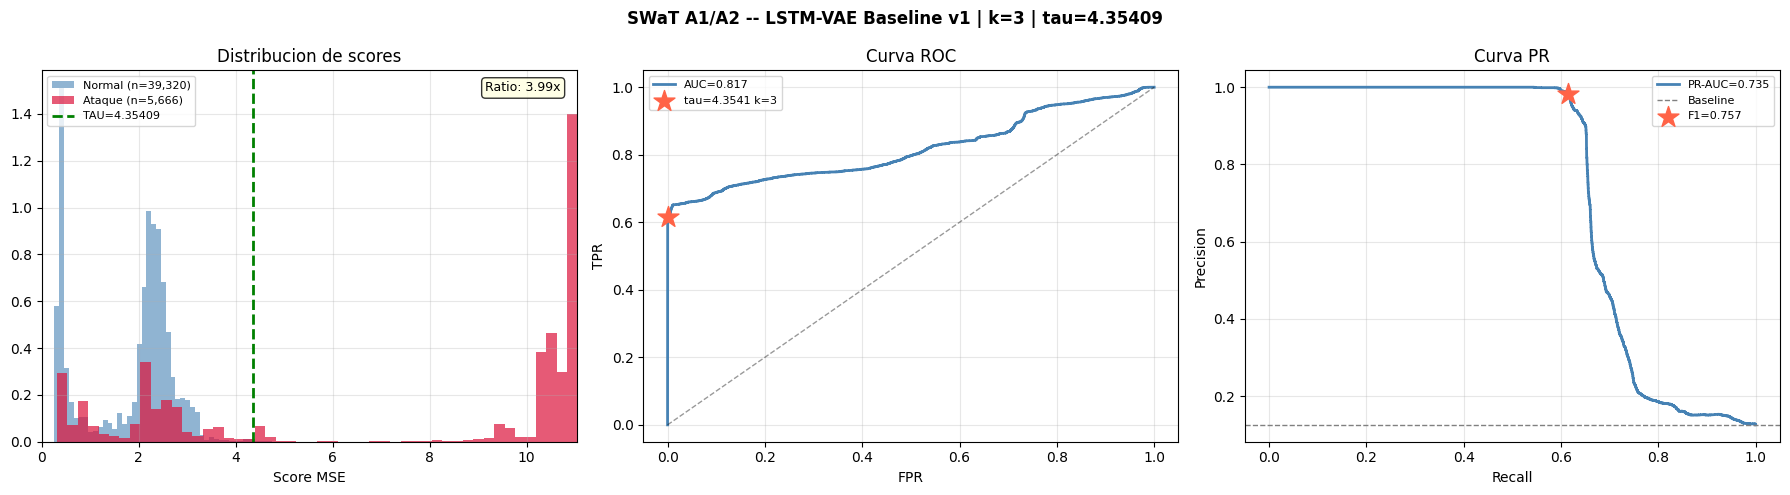

In [19]:
fprs_c, tprs_c, _ = roc_curve(y_filt, sc_filt)
precs_c, recs_c, _ = precision_recall_curve(y_filt, sc_filt)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribucion
mn_f = sc_filt[y_filt==0].mean(); ma_f = sc_filt[y_filt==1].mean()
axes[0].hist(sc_filt[y_filt==0], bins=100, alpha=0.6, density=True, color='steelblue',
             label=f'Normal (n={(y_filt==0).sum():,})')
axes[0].hist(sc_filt[y_filt==1], bins=50,  alpha=0.7, density=True, color='crimson',
             label=f'Ataque (n={(y_filt==1).sum():,})')
axes[0].axvline(TAU_OPT, color='green', lw=2, linestyle='--', label=f'TAU={TAU_OPT:.5f}')
axes[0].text(0.97, 0.97, f'Ratio: {ma_f/mn_f:.2f}x', ha='right', va='top',
             transform=axes[0].transAxes,
             bbox=dict(boxstyle='round',facecolor='lightyellow',alpha=0.8), fontsize=9)
axes[0].set_xlabel('Score MSE'); axes[0].set_title('Distribucion de scores')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, np.percentile(sc_filt, 99.5))

# ROC
axes[1].plot(fprs_c, tprs_c, color='steelblue', lw=2, label=f'AUC={auc_filt:.3f}')
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[1].scatter(fpr, rec, marker='*', s=250, color='tomato', zorder=5,
                label=f'tau={TAU_OPT:.4f} k={CONSEC_K}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# PR
axes[2].plot(recs_c, precs_c, color='steelblue', lw=2, label=f'PR-AUC={pr_auc:.3f}')
axes[2].axhline(y_filt.mean(), color='gray', linestyle='--', lw=1, label='Baseline')
axes[2].scatter(rec, prec, marker='*', s=250, color='tomato', zorder=5,
                label=f'F1={f1:.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Curva PR'); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'SWaT A1/A2 -- LSTM-VAE Baseline v1 | k={CONSEC_K} | tau={TAU_OPT:.5f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'eval_dist_roc_pr.png'), dpi=120, bbox_inches='tight')
plt.show()


### 8e. Score temporal y sweep de tau

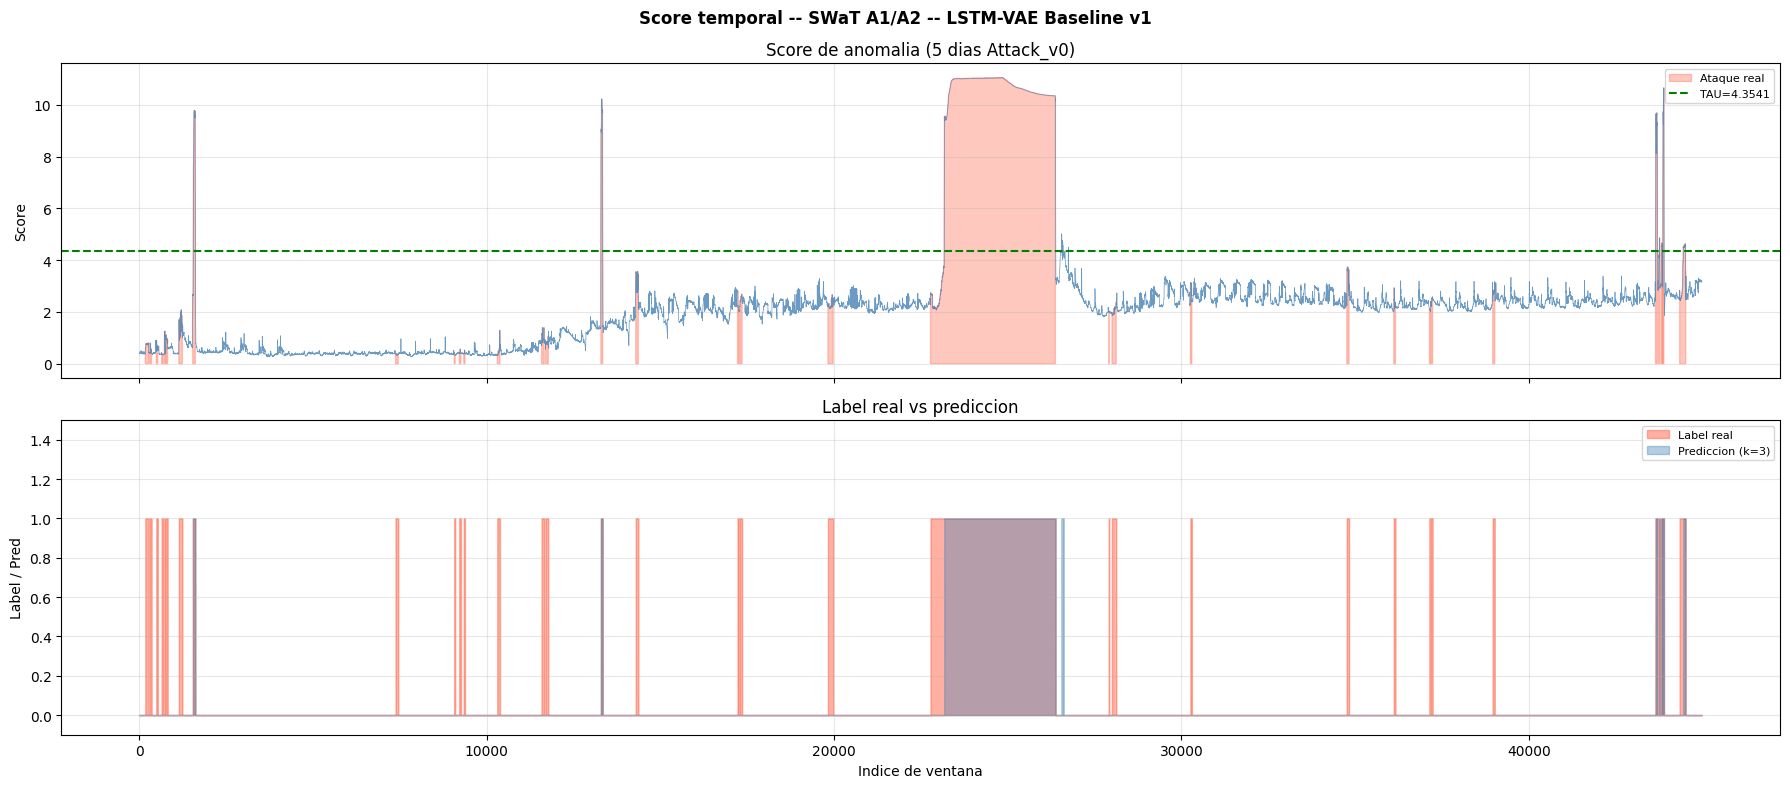

In [20]:
# Score temporal
t_idx = np.arange(len(df_wins))
pred_all = consec_filter(scores, TAU_OPT, CONSEC_K)

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
axes[0].plot(t_idx, scores, color='steelblue', lw=0.5, alpha=0.8)
axes[0].fill_between(t_idx, 0, scores, where=(y_all==1),
                     color='tomato', alpha=0.35, label='Ataque real')
axes[0].axhline(TAU_OPT, color='green', lw=1.5, linestyle='--', label=f'TAU={TAU_OPT:.4f}')
axes[0].set_ylabel('Score'); axes[0].set_title('Score de anomalia (5 dias Attack_v0)')
axes[0].legend(fontsize=8, loc='upper right'); axes[0].grid(True, alpha=0.3)

axes[1].fill_between(t_idx, 0, y_all.astype(float),
                     color='tomato', alpha=0.5, label='Label real')
axes[1].fill_between(t_idx, 0, pred_all.astype(float),
                     color='steelblue', alpha=0.4, label=f'Prediccion (k={CONSEC_K})')
axes[1].set_xlabel('Indice de ventana'); axes[1].set_ylabel('Label / Pred')
axes[1].set_title('Label real vs prediccion')
axes[1].set_ylim(-0.1, 1.5)
axes[1].legend(fontsize=8, loc='upper right'); axes[1].grid(True, alpha=0.3)

plt.suptitle('Score temporal -- SWaT A1/A2 -- LSTM-VAE Baseline v1',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'score_temporal.png'), dpi=120, bbox_inches='tight')
plt.show()


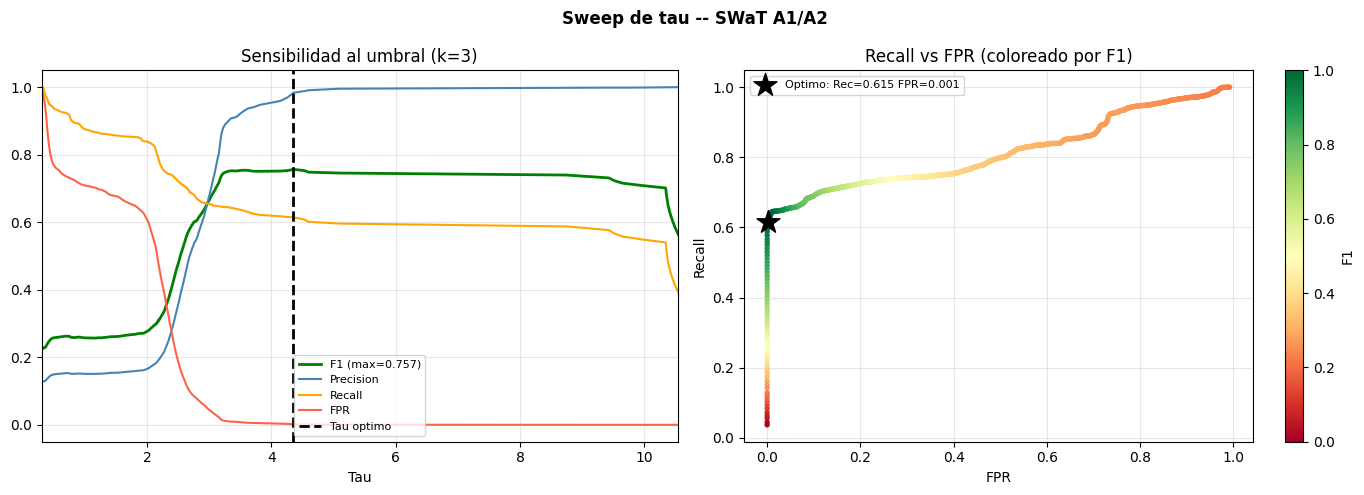

In [21]:
# Sweep de tau -- sensibilidad al umbral
taus_sw = np.percentile(sc_filt, np.linspace(0.5, 99.5, 800))
sw_f1, sw_prec, sw_rec, sw_fpr = [], [], [], []
for tau in taus_sw:
    pr = consec_filter(sc_filt, tau, CONSEC_K)
    tp_ = ((pr==1)&(y_filt==1)).sum(); fp_ = ((pr==1)&(y_filt==0)).sum()
    fn_ = ((pr==0)&(y_filt==1)).sum(); tn_ = ((pr==0)&(y_filt==0)).sum()
    p_ = tp_/(tp_+fp_+1e-10); r_ = tp_/(tp_+fn_+1e-10)
    sw_f1.append(2*p_*r_/(p_+r_+1e-10))
    sw_prec.append(p_); sw_rec.append(r_); sw_fpr.append(fp_/(fp_+tn_+1e-10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(taus_sw, sw_f1,   color='green',     lw=2,   label=f'F1 (max={max(sw_f1):.3f})')
axes[0].plot(taus_sw, sw_prec, color='steelblue', lw=1.5, label='Precision')
axes[0].plot(taus_sw, sw_rec,  color='orange',    lw=1.5, label='Recall')
axes[0].plot(taus_sw, sw_fpr,  color='tomato',    lw=1.5, label='FPR')
axes[0].axvline(TAU_OPT, color='black', lw=2, linestyle='--', label=f'Tau optimo')
axes[0].set_xlabel('Tau'); axes[0].set_xlim(taus_sw[0], np.percentile(sc_filt, 95))
axes[0].set_title(f'Sensibilidad al umbral (k={CONSEC_K})')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].scatter(sw_fpr, sw_rec, c=sw_f1, cmap='RdYlGn', s=8, zorder=3)
best_sw = np.argmax(sw_f1)
axes[1].scatter(sw_fpr[best_sw], sw_rec[best_sw], marker='*', s=300, color='black', zorder=5,
                label=f'Optimo: Rec={sw_rec[best_sw]:.3f} FPR={sw_fpr[best_sw]:.3f}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('Recall')
axes[1].set_title('Recall vs FPR (coloreado por F1)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.colorbar(plt.cm.ScalarMappable(cmap='RdYlGn'), ax=axes[1], label='F1')

plt.suptitle('Sweep de tau -- SWaT A1/A2', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'tau_sweep.png'), dpi=120, bbox_inches='tight')
plt.show()


## 9. Guardar artefactos

In [22]:
torch.save(model.state_dict(), SAVE_DIR / 'model_state.pt')

tau_dict = {f'p{str(p).replace(".","_")}': float(np.percentile(scores[y_all==0], p))
            for p in [90, 95, 97.5, 99, 99.5]}
tau_dict['optimal_k3'] = float(TAU_OPT)
with open(SAVE_DIR / 'tau_dict.json', 'w') as f:
    json.dump(tau_dict, f, indent=4)

config = {
    'version'          : 'lstm_vae_swat_a1a2_v1',
    'dataset_train'    : 'SWaT_Dataset_Normal_v1.xlsx (7 dias)',
    'dataset_eval'     : 'SWaT_Dataset_Attack_v0.xlsx (5 dias, 41 ataques)',
    'split'            : 'chronological_60_20_20 sobre Normal_v1',
    'window_size'      : WINDOW_SIZE,
    'stride'           : STRIDE,
    'clip_val'         : CLIP_VAL,
    'warmup_sec'       : WARMUP_SEC,
    'score_formula'    : 'alpha*MSE_cont + (1-alpha)*MSE_disc  [KL solo train]',
    'n_sensors'        : len(ALL_SENSOR_COLS),
    'n_continuous'     : len(CONTINUOUS_COLS),
    'n_discrete'       : len(DISCRETE_COLS),
    'disc_summary_dim' : DISC_DIM,
    'model_params'     : {
        'hidden_size': HIDDEN_SIZE, 'num_layers': NUM_LAYERS,
        'latent_dim' : LATENT_DIM,  'disc_hidden': DISC_HIDDEN,
        'alpha': float(ALPHA), 'beta': float(BETA),
        'dropout': float(DROPOUT), 'lr': float(LR), 'batch_size': BATCH_SIZE,
    },
    'training'         : {'best_epoch': best_ep, 'best_val_loss': float(best_val),
                          'n_windows_train': int(len(X_tr_c)),
                          'n_windows_val':   int(len(X_va_c))},
    'eval_protocol'    : {
        'consecutive_k' : CONSEC_K,
        'tau_optimal'   : float(TAU_OPT),
        'excluded_ids'  : EXCLUDED_IDS,
    },
    'metrics_all_attacks': {
        'roc_auc'   : float(roc_auc_score(y_all, scores)),
        'ratio_atk' : float(ma / mn),
    },
    'metrics_baseline' : {
        'roc_auc'   : float(auc_filt),
        'pr_auc'    : float(pr_auc),
        'f1'        : float(f1),
        'recall'    : float(rec),
        'precision' : float(prec),
        'fpr'       : float(fpr),
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
    },
    'continuous_cols'  : CONTINUOUS_COLS,
    'discrete_cols'    : DISCRETE_COLS,
}
with open(SAVE_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=4)

print('Artefactos guardados en:', SAVE_DIR.resolve())
for fp_ in sorted(SAVE_DIR.iterdir()): print(f'  {fp_.name}')
print()
print('='*60)
print('RESUMEN BASELINE SWaT A1/A2 -- LSTM-VAE v1')
print('='*60)
print(f'  ROC-AUC   : {auc_filt:.4f}  |  PR-AUC    : {pr_auc:.4f}')
print(f'  F1        : {f1:.3f}   |  Recall    : {rec:.3f}')
print(f'  Precision : {prec:.3f}   |  FPR       : {fpr:.3f}')
print(f'  tau optimo: {TAU_OPT:.5f}  |  k         : {CONSEC_K}')
print(f'  Train wins: {len(X_tr_c):,}  |  Best ep   : {best_ep}')
print('='*60)


Artefactos guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_swat_a1a2_v1
  config.json
  disc_max_dict.pkl
  error_dist_referencia.png
  eval_dist_roc_pr.png
  model_state.pt
  scaler_cont.pkl
  score_temporal.png
  tau_dict.json
  tau_sweep.png
  training_curve.png

RESUMEN BASELINE SWaT A1/A2 -- LSTM-VAE v1
  ROC-AUC   : 0.8170  |  PR-AUC    : 0.7346
  F1        : 0.757   |  Recall    : 0.615
  Precision : 0.984   |  FPR       : 0.001
  tau optimo: 4.35409  |  k         : 3
  Train wins: 29,587  |  Best ep   : 54
